# Training CGNet in Antarctic Region with PSL AND TMQ

Purpose:
--------
The purpose of this notebook is to train CGnet for machine learning detection of atmospheric rivers and tropical cyclones.\
See ClimateNet repo here: https://github.com/andregraubner/ClimateNet

Note:
-----
In order to run this notebook, users should request 1 node, 2 cpu, 92GB mem, 2 V100 GPU

Authors/Contributors:
---------------------
* Teagan King
* John Truesdale
* Katie Dagon

### Prerequisites:

- copy files to psl_tmq dir:
`/glade/campaign/cgd/ccr/tking/cgnet/underlying_processed_training_data/sh_polar/psl_tmq/`
- make sure types match for time # unable to find var time? skipping for now....
```
cd tmq
foreach i (*.nc)
    ncap2 -s time=float(time) $i  ncap/$i # add quotes!
```
- merge files
```
foreach i (*.nc)
ncks -A $i ../tmq/$i
# some warnings about variable time not being double=float...
```

- separate by year

## Import libraries

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/glade/work/tking/cgnet/ClimateNet")  # append path to ClimateNet repo
from climatenet.utils.data import ClimateDatasetLabeled, ClimateDataset
from climatenet.models import CGNet
from climatenet.utils.utils import Config
from climatenet.track_events import track_events
from climatenet.analyze_events import analyze_events
# from climatenet.just_polar_plots_analyze_events import just_polar_plots_analyze_events
from climatenet.visualize_events import visualize_events
import climatenet.analyze_polar_events

from IPython.display import Image
from os import path

import torch
import xarray as xr
import dask

## Config file
Use `get_averages_and_standard_devs.ipynb` to calculate means/stds for given training dataset.

In [2]:
cd /glade/work/tking/cgnet/ML-extremes/trained_models/config_102025_PSL_TMQ

/glade/work/tking/cgnet/ML-extremes/trained_models/config_102025_PSL_TMQ


In [3]:
config = Config('config.json')

In [4]:
config.train_batch_size

4

## Confirm GPU resources

In [5]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())

True
2


## Instantiate CGNet model given config file

In [7]:
%%time
cgnet = CGNet(config)

CPU times: user 1.55 s, sys: 768 ms, total: 2.32 s
Wall time: 7 s


In [8]:
cgnet.optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    eps: 1e-08
    lr: 0.001
    weight_decay: 0
)

## Set train, test data

In [9]:
train_path = '/glade/work/tking/cgnet/QA_xml/all_antarctic_converted_masks/split_files'

train = ClimateDatasetLabeled(path.join(train_path+'/train'), config)
test = ClimateDatasetLabeled(path.join(train_path+'/test'), config)

In [10]:
train.fields

{'psl': {'mean': 101001.370879, 'std': 1387.300643},
 'tmq': {'mean': 21.593790761325735, 'std': 13.6215941728325}}

In [11]:
train.length

622

In [12]:
config.epochs

20

## Train model

Memory use holding at ~14GB during training\
Each epoch takes ~1 min to run

NOTE: This was failing when pred and train batch size were set to 16 in config; it runs with both set to 4.

In [13]:
cgnet.train(train)
# IOU mean should be around 0.75 after all epochs?

  0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1:


  0%|          | 0/156 [00:00<?, ?it/s]

Epoch stats:
[[7.51490949e+08 2.93936990e+07 0.00000000e+00]
 [3.29750010e+07 1.15990390e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.92336676 0.15681213 1.        ] , mean:  0.6933929654083745
Epoch 2:


  0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch stats:
[[7.58910358e+08 2.19742900e+07 0.00000000e+00]
 [1.94636340e+07 2.51104060e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.94822514 0.37732586 1.        ] , mean:  0.7751836658628676
Epoch 19:


  0%|          | 0/156 [00:00<?, ?it/s]

Epoch stats:
[[7.58379873e+08 2.25047750e+07 0.00000000e+00]
 [1.89939420e+07 2.55800980e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.94811873 0.38134392 1.        ] , mean:  0.776487548742339
Epoch 20:


Loss: 0.6090795397758484: 100%|██████████| 156/156 [02:02<00:00,  1.27it/s]

Epoch stats:
[[7.59145057e+08 2.17395910e+07 0.00000000e+00]
 [1.88643480e+07 2.57096920e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.94922915 0.38769845 1.        ] , mean:  0.7789758657853708


### IOU/loss across epochs - 10/2025 model

In [6]:
# LOSS AND IOU FROM ABOVE
Loss_tmq_20_epochs = [0.6338358521461487,0.6103487610816956,0.6162010431289673,0.6143033504486084,0.6184302568435669,0.6080795526504517,0.620759129524231,0.6077368259429932,
                     0.6110032796859741,0.6136678457260132,0.6162186861038208,0.6158632040023804,0.6107096076011658,0.6068084239959717,0.6066470146179199,0.6064047813415527,
                      0.6183897256851196, 0.6028591394424438,0.6245251893997192,0.6090795397758484
]

iou_tmq_20_epochs = [ [0.92336676, 0.15681213, 1] , [0.93785522, 0.22836772, 1] , [0.93839376, 0.25130584, 1] , [0.93874885, 0.264805, 1] ,
 [0.93857226, 0.2706492,  1] , [0.93893947, 0.28359016, 1] , [0.94032758, 0.28971527, 1] , [0.941384,   0.29798074, 1] , [0.94155727, 0.30833206, 1] ,
 [0.94282554, 0.31997474, 1.        ] ,
 [0.94230635, 0.32527408, 1.        ] ,
 [0.94419239, 0.33160696, 1.        ] ,
 [0.94421785, 0.33557745, 1.        ] ,
 [0.94537948, 0.34672043, 1.        ] ,
 [0.94676821, 0.35447599, 1.        ] ,
 [0.94675714, 0.35957698, 1.        ] ,
 [0.9471343,  0.36750243, 1.        ] ,
 [0.94822514, 0.37732586, 1.        ] ,
 [0.94811873, 0.38134392, 1.        ] ,
 [0.94922915, 0.38769845, 1.        ] ]

In [7]:
epoch_range = np.arange(1, config.epochs+1)

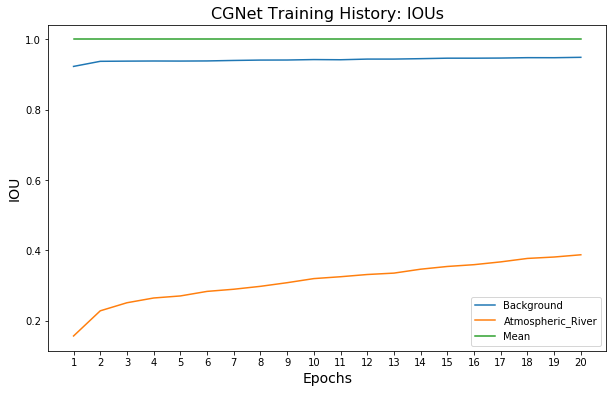

In [10]:
plt.figure(figsize=(10,6))
plt.plot(epoch_range, iou_tmq_20_epochs)
# plt.plot(epoch_range, iou_mean, color='k', linewidth=2)
plt.ylabel('IOU', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.xticks(epoch_range);
plt.title('CGNet Training History: IOUs', fontsize=16)
plt.legend(config.labels+['Mean', 'Test Data']);

## Save out model

In [14]:
cgnet.save_model('/glade/work/tking/cgnet/ML-extremes/trained_models/trained_cgnet.102025_PSL_TMQ')

## Load in previously trained model

In [ ]:
# cgnet.load_model('/glade/work/tking/cgnet/ML-extremes/trained_models/trained_cgnet.102025_PSL_TMQ')

## Predict on test data
Need to reload test data as `ClimateDataset` in order to use `.predict`

In [15]:
test_path = train_path+"/test"
test_data = ClimateDataset(test_path, config)

In [16]:
%%time
test_masks = cgnet.predict(test_data)

 49%|████▊     | 19/39 [00:22<00:23,  1.18s/it]


RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same

## Set inference data

In [ ]:
cd /glade/work/tking/cgnet/ML-extremes/trained_models/config_102025_PSL_TMQ_INFERENCE/
# Need to set this up for inference data means/std!

In [ ]:
config = Config('config.json')

In [ ]:
config.description

In [ ]:
config.train_batch_size

In [34]:
inference_path = '/glade/campaign/cgd/ccr/tking/cgnet/underlying_processed_training_data/sh_polar/psl_tmq/split_xy/'
inference = ClimateDataset(inference_path, config)  # could test different config with std/means for inference data

In [35]:
inference.fields

{'psl': {'mean': 101001.370879, 'std': 1387.300643},
 'tmq': {'mean': 21.593790761325735, 'std': 13.6215941728325}}

In [36]:
inference.length

14595

## Inference mode
This is now done more systematically in `cgnet_run_pre_trained_model.ipynb`.

In [37]:
%%time
class_masks = cgnet.predict(inference)

100%|██████████| 3649/3649 [51:43<00:00,  1.18it/s] 


CPU times: user 15min 8s, sys: 7min 39s, total: 22min 48s
Wall time: 1h 4min 35s


### Look at class masks

In [ ]:
%%time
class_masks.to_netcdf("/glade/derecho/scratch/tking/cgnet/PSL_TMQ_Model/class_masks_102025.nc")

## Track events

Note: memory spikes here - resource intensive!

In [ ]:
%%time
event_masks = track_events(class_masks)

identifying connected components..


### Save out event masks

In [ ]:
# %%time
event_masks.to_netcdf("/glade/derecho/scratch/tking/cgnet/PSL_TMQ_Model/event_masks_102025.nc")

## Analyze events

In [ ]:
climatenet.analyze_events.just_polar_plots_analyze_events(event_masks, class_masks, "/glade/derecho/scratch/tking/cgnet/PSL_TMQ_model/")

In [ ]:
Image("/glade/derecho/scratch/tking/cgnet/PSL_TMQ_Model/genesis_frequency_ar.png")

In [ ]:
Image("/glade/derecho/scratch/tking/cgnet/PSL_TMQ_Model/termination_frequency_ar.png")

In [ ]:
Image("/glade/derecho/scratch/tking/cgnet/PSL_TMQ_Model/global_frequency_ar.png")